In [1]:
import gffpandas.gffpandas as gffpd
import pandas as pd
import numpy as np

In [2]:
annot = pd.read_csv("../hpy_annot.tsv",sep='\t')#hpy annotation file
annot = annot.drop(columns=["seqname", "source", "feature", "score", "frame", "Prot_Size(est)", "attribute"]) #clean
merged = pd.read_csv("methylation_df.csv")

In [4]:
ctrl7 = merged[merged['sample'] == 'ctrl pH7']
ctrl5 = merged[merged['sample'] == 'ctrl pH5']
ars7 = merged[merged['sample'] == 'arsS pH7']
ars5 = merged[merged['sample'] == 'arsS pH5']

## Differences
- between control pH 5 and control pH 7 (changes in methylome due to acid shock)
- between arsS pH 5 and arsS pH 7 (changes in methylome due to acidity, independent of arsS)
- between arsS pH 5 and control pH 5 (changes in methylome at acidic conditions due to arsS)
- between arsS pH 7 and control pH 7 (changes in methylome in normal conditions due to arsS)

In [5]:
# between control pH 5 and control pH 7 (changes in methylome due to acid shock)
unique_ctrl7 = ctrl7[~ctrl7['start'].isin(ctrl5['start'])]
unique_ctrl5 = ctrl5[~ctrl5['start'].isin(ctrl7['start'])]

ctrl_unique = pd.concat([unique_ctrl7, unique_ctrl5], ignore_index=True)

In [7]:
ctrl_unique.to_csv('./differences/ctrl_diff_all.csv', index=False)

In [6]:
# between arsS pH 5 and arsS pH 7 (changes in methylome due to acidity, independent of arsS)
unique_ars7 = ars7[~ars7['start'].isin(ars5['start'])]
unique_ars5 = ars5[~ars5['start'].isin(ars7['start'])]

ars_unique = pd.concat([unique_ars7, unique_ars5], ignore_index=True)

In [9]:
ars_unique.to_csv('arsS_diff_all.csv', index=False)

In [7]:
# between arsS pH 5 and control pH 5 (changes in methylome at acidic conditions due to arsS)
acid_ctrl5 = ctrl5[~ctrl5['start'].isin(ars5['start'])]
acid_ars5 = ars5[~ars5['start'].isin(ctrl5['start'])]

acidic_unique = pd.concat([acid_ctrl5, acid_ars5], ignore_index=True)

In [30]:
acidic_unique.to_csv('pH5_diff_all.csv', index=False)

In [8]:
# between arsS pH 7 and control pH 7 (changes in methylome in normal conditions due to arsS)
normal_ctrl7 = ctrl7[~ctrl7['start'].isin(ars7['start'])]
normal_ars7 = ars7[~ars7['start'].isin(ctrl7['start'])]

normal_unique = pd.concat([normal_ctrl7, normal_ars7], ignore_index=True)

In [32]:
normal_unique.to_csv('pH7_diff_all.csv', index=False)

### Analyzing

In [11]:
cdr_ctrl = ctrl_unique[
    (ctrl_unique['Classification'] == 'Coding Region') | 
    (ctrl_unique['Classification'] == 'Promoter and Coding Region')
]

In [13]:
cdr_ctrl

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
0,107,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2946,2946,122,+,.,...,GCAAATGCCGCACTAGAATGCGCGAAATTAGACATTGACAT,544,NaN,59.0,NaN,Coding Region,NaN,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",NaN
1,191,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,5835,5835,127,+,.,...,TTATGCCCTAATTCTTGCGTGGCGCTTAATAATTGCGAATA,521,NaN,NaN,NaN,Coding Region,NaN,HP0009,CELL ENVELOPE,NaN
2,195,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,6033,6033,108,+,.,...,CTAAAATCAAGTATCGTGCGCGCCAACAACTCAGATTGCTT,526,NaN,26.0,NaN,Coding Region,NaN,HP0009,CELL ENVELOPE,NaN
4,258,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,7831,7831,127,+,.,...,CTAGCGTTAAAACCAAAATGCCCTTCGTGTTTTTCTACTTC,469,NaN,102.0,NaN,Coding Region,NaN,HP0010,CELLULAR PROCESSES,NaN
5,262,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,7981,7981,124,+,.,...,TTCAAATGCACTTTTTGAGCCGCGCGAATGAGAGCCGCACC,523,NaN,83.0,NaN,Coding Region,NaN,HP0010,CELLULAR PROCESSES,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114,118679,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,1648914,1648914,80,-,.,...,CATGACTAAAAAGGAATTTCTAGTCCCTACAAGGGGAAATA,436,NaN,NaN,NaN,Coding Region,NaN,HP1565,CELL ENVELOPE,NaN
1115,118761,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1651173,1651173,94,-,.,...,GATTAGTGTTTTTCTTTTTGCGTTCCCAACCCACTAGCGTA,444,NaN,59.0,NaN,Coding Region,NaN,HP1569,HYPOTHETICAL PROTEIN,NaN
1116,118876,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1653947,1653947,129,-,.,...,AAATTGCTGAAATCATCAACATAGAGACTGAAGAACTCGCT,434,NaN,86.0,NaN,Coding Region,NaN,HP1573,HYPOTHETICAL PROTEIN,NaN
1117,118897,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1654536,1654536,92,-,.,...,ACTCAATGCGTGATTCCTGGCGCGGACATGAAGGATTTGAA,432,NaN,48.0,NaN,Coding Region,NaN,HP1573,HYPOTHETICAL PROTEIN,NaN


In [21]:
# Select only unique genes based on 'CodingRegion_ID'
unique_genes_df = cdr_ctrl.drop_duplicates(subset=['CodingRegion_ID'])

# Count occurrences of each unique 'CodingRegion_gene_type'
gene_type_counts = unique_genes_df['CodingRegion_gene_type'].value_counts()

# Display the results
print(gene_type_counts)

CodingRegion_gene_type
HYPOTHETICAL PROTEIN                                          243
CELL ENVELOPE                                                  70
REPLICATION                                                    53
TRANSLATION                                                    51
TRANSPORT AND BINDING PROTEINS                                 49
ENERGY METABOLISM                                              43
CELLULAR PROCESSES                                             40
AMINO-ACID BIOSYNTHESIS                                        26
BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS     22
PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES              18
OTHER CATEGORIES                                               15
REGULATORY FUNCTIONS                                           11
CENTRAL INTERMEDIARY METABOLISM                                 9
FATTY ACID AND PHOSPHOLIPID METABOLISM                          9
TRANSCRIPTION                                        

In [15]:
cdr_ctrl['CodingRegion_ID'].value_counts()

CodingRegion_ID
HP0922    12
HP1198     8
HP0887     8
HP1241     6
HP0238     6
          ..
HP1460     1
HP0388     1
HP1428     1
HP1421     1
HP1278     1
Name: count, Length: 666, dtype: int64

In [14]:
cdr_ctrl['CodingRegion_gene_type'].value_counts()

CodingRegion_gene_type
HYPOTHETICAL PROTEIN                                          336
CELL ENVELOPE                                                 130
TRANSLATION                                                    89
REPLICATION                                                    87
TRANSPORT AND BINDING PROTEINS                                 78
CELLULAR PROCESSES                                             69
ENERGY METABOLISM                                              67
AMINO-ACID BIOSYNTHESIS                                        42
PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES              35
BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS     34
OTHER CATEGORIES                                               20
TRANSCRIPTION                                                  18
REGULATORY FUNCTIONS                                           16
CENTRAL INTERMEDIARY METABOLISM                                14
FATTY ACID AND PHOSPHOLIPID METABOLISM               

In [10]:
cdr_ctrl.to_csv('cdr_ctrl7n5.csv', index=False)

In [22]:
cell_env = cdr_ctrl[cdr_ctrl['CodingRegion_gene_type'] == 'CELL ENVELOPE']

In [30]:
full_value_counts = cell_env['CodingRegion_ID'].value_counts().to_string()
print(full_value_counts)

CodingRegion_ID
HP0922    12
HP0610     5
HP0115     4
HP0752     4
HP0870     4
HP0623     4
HP0815     3
HP0839     3
HP0295     3
HP1565     3
HP0351     3
HP0908     3
HP0645     3
HP0009     2
HP1105     2
HP1177     2
HP1157     2
HP0858     2
HP1243     2
HP1494     2
HP0379     2
HP0567     2
HP0923     2
HP0867     2
HP1119     2
HP0353     2
HP0655     2
HP0208     2
HP0317     2
HP0421     2
HP1501     2
HP0725     2
HP0679     1
HP0229     1
HP0326     1
HP0352     1
HP0227     1
HP0494     1
HP0826     1
HP0196     1
HP0740     1
HP0743     1
HP0178     1
HP0175     1
HP0957     1
HP1031     1
HP1274     1
HP1420     1
HP1450     1
HP1456     1
HP0289     1
HP1571     1
HP1041     1
HP1559     1
HP0912     1
HP1113     1
HP0651     1
HP1156     1
HP0648     1
HP0493     1
HP1191     1
HP0685     1
HP1275     1
HP1342     1
HP1373     1
HP1375     1
HP1462     1
HP1469     1
HP0859     1
HP0830     1


In [12]:
prom_ctrl = ctrl_unique[
    (ctrl_unique['Classification'] == 'Promoter Region') | 
    (ctrl_unique['Classification'] == 'Promoter and Coding Region')
]
prom_ctrl

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
101,8410,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,230587,230587,124,+,.,...,TAGCACTTGCAACATTATTCATTTACGCTGCTTTTATGCTA,429,NaN,106.0,NaN,Promoter Region,HP0222,NaN,NaN,HYPOTHETICAL PROTEIEN
134,12041,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,334196,334196,83,+,.,...,TTGCTATTAGAATGTATTTGGGGTATTATAGCATAAAGCGT,460,NaN,NaN,NaN,Promoter Region,HP0317,NaN,NaN,CELL ENVELOPE
211,20531,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,575202,575202,148,-,.,...,TATCATAGATAAATATCAGGCCTTGAGGCAAATGTATCAAC,483,NaN,18.0,NaN,Promoter and Coding Region,HP0543,HP0544,CELLULAR PROCESSES,CELLULAR PROCESSES
290,29910,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,831084,831084,166,+,.,...,ACCTAATCTTGCTTAAAAACACCCTTTCTGAATTTTAAGCC,456,NaN,113.0,NaN,Promoter Region,HP0777,NaN,NaN,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES"
425,43688,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1228395,1228395,126,+,.,...,GAAAGCGTGTTGTATGACAGCGCGAGCGATTTGAACGAAGC,443,NaN,111.0,NaN,Promoter and Coding Region,HP1162,HP1163,HYPOTHETICAL PROTEIN,HYPOTHETICAL PROTEIEN
500,52223,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1459883,1459883,334,+,.,...,TATTATCCATTTGCTTATTAATAATTGGTTGTTAATTTTGG,466,ATTAAT,363.0,ATTAAT,Promoter Region,HP1399,NaN,NaN,ENERGY METABOLISM
691,74956,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,421537,421537,112,-,.,...,CCCCACGCTTCAGCTTGGCTAGCGCTCAAGTCTTTAGCGCT,423,NaN,63.0,NaN,Promoter Region,HP0408,NaN,NaN,HYPOTHETICAL PROTEIEN
889,95009,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,987006,987006,93,-,.,...,ATAGCGCATACCAATATTTCCGGTGATATTAATATCTTTAT,365,NaN,45.0,NaN,Promoter and Coding Region,HP0923,HP0922,CELL ENVELOPE,CELL ENVELOPE
1027,110292,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1414305,1414305,117,+,.,...,GCATAAATATAGCCTAAAACCTCTAGCGGCTCAAAAGAGTG,358,NaN,85.0,NaN,Promoter and Coding Region,HPnc7100,HP1353,HYPOTHETICAL PROTEIN,NaN
1047,112733,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1484468,1484468,147,-,.,...,CCTGAACTAAACCTCAAATCCTTAGGCGCTAAAACGCCCTA,483,NaN,107.0,NaN,Promoter and Coding Region,HP1414,HP1413,HYPOTHETICAL PROTEIN,HYPOTHETICAL PROTEIEN


In [15]:
annot[annot['HP_number'] == 'HP0317']

,HP_number,start,end,Putative_Id,Orf_Size,strand
316,HP0317,331857,334091,outer membrane protein (omp9),2234,-


In [13]:
prom_ctrl.to_csv('promoter_ctrl7n5.csv', index=False)

In [26]:
cdr_ars = ars_unique[
    (ars_unique['Classification'] == 'Coding Region') | 
    (ars_unique['Classification'] == 'Promoter and Coding Region')
]
cdr_ars

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
0,119421,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,113,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,531,NaN,71.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
1,119451,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2946,2946,132,+,.,...,GCAAATGCCGCACTAGAATGCGCGAAATTAGACATTGACAT,520,NaN,63.0,NaN,Coding Region,NaN,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",NaN
2,119726,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,10528,10528,101,+,.,...,GCTCAAGTGGTGGGTTTTGGAGGGCGCACCTTAAAAGAAAA,535,GAGG,121.0,GAGG,Coding Region,NaN,HP0012,REPLICATION,NaN
3,119809,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,12842,12842,108,-,.,...,GATATAAAAAGGGAATAGCCCCTTAGGGGCGTCCTTTTCTT,452,NaN,104.0,NaN,Coding Region,NaN,HP0014,HYPOTHETICAL PROTEIN,NaN
4,120027,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,19392,19392,114,+,.,...,TGCTACGTGTTAGAGAGCGAACGCTTAGAAAAAAACGCCAA,549,NaN,69.0,NaN,Coding Region,NaN,HP0020,CENTRAL INTERMEDIARY METABOLISM,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,236183,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1640750,1640750,85,-,.,...,CAAATTACCCCCTATGAAGACCCCTTAGATGAAGGCGATGA,436,NaN,71.0,NaN,Coding Region,NaN,HP1558,CELL ENVELOPE,NaN
786,236239,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1642245,1642245,109,+,.,...,AGCGATTGTTACAAGCGAGCATAGGATTTTGCGCCTGAAAT,455,NaN,53.0,NaN,Coding Region,NaN,HP1560,CELLULAR PROCESSES,NaN
788,236605,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1652478,1652478,148,+,.,...,GCTATCTTGCGAATCGGAGTAGCGTTTGAAATGGCGTTCAA,428,NaN,111.0,NaN,Coding Region,NaN,HP1571,CELL ENVELOPE,NaN
789,236921,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1661662,1661662,116,+,.,...,CTAGCACGATAGGCAAAGTCAGCGCTCAAAGCGGGGCGTAT,439,NaN,74.0,NaN,Coding Region,NaN,HP1583,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",NaN


In [16]:
prom_ars = ars_unique[
    (ars_unique['Classification'] == 'Promoter Region') | 
    (ars_unique['Classification'] == 'Promoter and Coding Region')
]
prom_ars

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
0,119421,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,113,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,531,NaN,71.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
114,136831,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,495091,495091,131,+,.,...,TACACCCACAAAACAAACCGCCTCAAACTTTTAAAATACAA,471,NaN,100.0,NaN,Promoter Region,HP0473,NaN,NaN,TRANSPORT AND BINDING PROTEINS
313,164649,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1288530,1288530,126,-,.,...,TAAAAAGCGTTTTTTAAAAGCGTTTTTAAGCTAGTTTGTAT,546,NaN,90.0,NaN,Promoter Region,HP1212,NaN,NaN,ENERGY METABOLISM
349,169321,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1414305,1414305,152,+,.,...,GCATAAATATAGCCTAAAACCTCTAGCGGCTCAAAAGAGTG,495,NaN,107.0,NaN,Promoter and Coding Region,HPnc7100,HP1353,HYPOTHETICAL PROTEIN,NaN
357,170744,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1455842,1455842,174,-,.,...,AAGCTTTAAGCTACAATAGTATGTATGAAAGATTCACTTCA,560,NaN,125.0,NaN,Promoter Region,HP1394,NaN,NaN,HYPOTHETICAL PROTEIEN
363,171727,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1484468,1484468,157,-,.,...,CCTGAACTAAACCTCAAATCCTTAGGCGCTAAAACGCCCTA,568,NaN,119.0,NaN,Promoter and Coding Region,HP1414,HP1413,HYPOTHETICAL PROTEIN,HYPOTHETICAL PROTEIEN
379,173910,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1543942,1543942,138,+,.,...,AAAACGCCTTGATTTTGCGAAGTCCTTGTAATATAATCATA,567,RCGDAD,24.0,RCGDAD,Promoter and Coding Region,HPnc7890,HP1471,REPLICATION,NaN


In [17]:
prom_ctrl

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
101,8410,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,230587,230587,124,+,.,...,TAGCACTTGCAACATTATTCATTTACGCTGCTTTTATGCTA,429,NaN,106.0,NaN,Promoter Region,HP0222,NaN,NaN,HYPOTHETICAL PROTEIEN
134,12041,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,334196,334196,83,+,.,...,TTGCTATTAGAATGTATTTGGGGTATTATAGCATAAAGCGT,460,NaN,NaN,NaN,Promoter Region,HP0317,NaN,NaN,CELL ENVELOPE
211,20531,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,575202,575202,148,-,.,...,TATCATAGATAAATATCAGGCCTTGAGGCAAATGTATCAAC,483,NaN,18.0,NaN,Promoter and Coding Region,HP0543,HP0544,CELLULAR PROCESSES,CELLULAR PROCESSES
290,29910,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,831084,831084,166,+,.,...,ACCTAATCTTGCTTAAAAACACCCTTTCTGAATTTTAAGCC,456,NaN,113.0,NaN,Promoter Region,HP0777,NaN,NaN,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES"
425,43688,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1228395,1228395,126,+,.,...,GAAAGCGTGTTGTATGACAGCGCGAGCGATTTGAACGAAGC,443,NaN,111.0,NaN,Promoter and Coding Region,HP1162,HP1163,HYPOTHETICAL PROTEIN,HYPOTHETICAL PROTEIEN
500,52223,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1459883,1459883,334,+,.,...,TATTATCCATTTGCTTATTAATAATTGGTTGTTAATTTTGG,466,ATTAAT,363.0,ATTAAT,Promoter Region,HP1399,NaN,NaN,ENERGY METABOLISM
691,74956,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,421537,421537,112,-,.,...,CCCCACGCTTCAGCTTGGCTAGCGCTCAAGTCTTTAGCGCT,423,NaN,63.0,NaN,Promoter Region,HP0408,NaN,NaN,HYPOTHETICAL PROTEIEN
889,95009,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,987006,987006,93,-,.,...,ATAGCGCATACCAATATTTCCGGTGATATTAATATCTTTAT,365,NaN,45.0,NaN,Promoter and Coding Region,HP0923,HP0922,CELL ENVELOPE,CELL ENVELOPE
1027,110292,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1414305,1414305,117,+,.,...,GCATAAATATAGCCTAAAACCTCTAGCGGCTCAAAAGAGTG,358,NaN,85.0,NaN,Promoter and Coding Region,HPnc7100,HP1353,HYPOTHETICAL PROTEIN,NaN
1047,112733,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1484468,1484468,147,-,.,...,CCTGAACTAAACCTCAAATCCTTAGGCGCTAAAACGCCCTA,483,NaN,107.0,NaN,Promoter and Coding Region,HP1414,HP1413,HYPOTHETICAL PROTEIN,HYPOTHETICAL PROTEIEN


In [38]:
cdr_ars[cdr_ars['CodingRegion_ID'] == 'HP0312']

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
488,189904,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,328585,328585,145,+,.,...,GAGCCTCTTTTCACGCAAAAATAGGGCGCGAAATTTTATGC,408,NaN,218.0,NaN,Coding Region,NaN,HP0312,NaN,NaN
489,189912,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,328697,328697,93,+,.,...,TGGAGCGCGTTTGGGATTTGGCTGAGTTTGTTATTGCATCA,405,NaN,NaN,NaN,Coding Region,NaN,HP0312,NaN,NaN
490,189921,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,328920,328920,131,-,.,...,GGTTTCAAAACCCTTGATGCCGAGAAAATCCTTAAAACCCT,349,NaN,97.0,NaN,Coding Region,NaN,HP0312,NaN,NaN


In [35]:
cdr_ars['CodingRegion_ID'].value_counts()

CodingRegion_ID
HP1243    6
HP0662    4
HP0464    4
HP0123    4
HP0238    4
         ..
HP1054    1
HP1039    1
HP1037    1
HP1031    1
HP1571    1
Name: count, Length: 541, dtype: int64

In [37]:
cdr_ars['CodingRegion_gene_type'].value_counts()

CodingRegion_gene_type
HYPOTHETICAL PROTEIN                                          228
CELL ENVELOPE                                                  84
TRANSLATION                                                    64
TRANSPORT AND BINDING PROTEINS                                 57
REPLICATION                                                    56
ENERGY METABOLISM                                              51
CELLULAR PROCESSES                                             38
BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS     34
AMINO-ACID BIOSYNTHESIS                                        32
PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES              23
CENTRAL INTERMEDIARY METABOLISM                                16
OTHER CATEGORIES                                               16
FATTY ACID AND PHOSPHOLIPID METABOLISM                         13
REGULATORY FUNCTIONS                                           12
TRANSCRIPTION                                        

In [36]:
#cell_env = cdr_ars[cdr_ars['CodingRegion_gene_type'] == 'CELL ENVELOPE']
full_value_counts = cell_env['CodingRegion_ID'].value_counts().to_string()
print(full_value_counts)

CodingRegion_ID
HP1243    6
HP0289    4
HP0839    3
HP1558    2
HP0870    2
HP1157    2
HP1274    2
HP1429    2
HP0115    2
HP0752    2
HP0025    2
HP0254    2
HP0317    2
HP0610    2
HP0858    2
HP1177    2
HP1585    2
HP1155    2
HP0725    2
HP0567    2
HP0597    2
HP0326    2
HP0679    2
HP0815    1
HP0619    1
HP0351    1
HP0494    1
HP0549    1
HP0623    1
HP0178    1
HP0655    1
HP0325    1
HP0867    1
HP0923    1
HP1035    1
HP0295    1
HP1469    1
HP0379    1
HP0493    1
HP0079    1
HP1578    1
HP0638    1
HP0645    1
HP0648    1
HP0651    1
HP1156    1
HP1092    1
HP1031    1
HP0922    1
HP0913    1
HP0908    1
HP0896    1
HP0685    1
HP1571    1


In [39]:
normal_unique

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
0,18,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,679,679,191,-,.,...,AGGGCTTTGAAGCGATGAGCACCCTCATTGAATTGTTGAGC,568,NaN,163.0,NaN,Coding Region,NaN,HP0002,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",NaN
1,76,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2128,2128,135,+,.,...,TGAGTTGCAAGCGCGCATTCAAACGCTCTGTAAGCCATGAA,527,HHTCAVNNNNNNTGY,85.0,HHTCAVNNNNNNTGY,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
2,77,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,2136,2136,109,-,.,...,GCCAAGCGTTCATGGCTTACAGAGCGTTTGAATGCGCGCTT,550,NaN,NaN,NaN,Coding Region,NaN,HP0004,CENTRAL INTERMEDIARY METABOLISM,NaN
3,191,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,5835,5835,127,+,.,...,TTATGCCCTAATTCTTGCGTGGCGCTTAATAATTGCGAATA,521,NaN,NaN,NaN,Coding Region,NaN,HP0009,CELL ENVELOPE,NaN
4,206,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,6321,6321,177,+,.,...,TTTTGAGCGAAAGCCCTATCAGCAGAGGTGTAAGGATTGAA,536,HHTCAVNNNNNNTGY,141.0,HHTCAVNNNNNNTGY,Coding Region,NaN,HP0009,CELL ENVELOPE,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,177147,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1636359,1636359,128,+,.,...,TTTTGTAAAGAAATGAGCGAAGCGATTTTAGAGGGGCGAGA,520,RCGDAD,83.0,RCGDAD,Coding Region,NaN,HP1554,TRANSLATION,NaN
1542,177308,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,1640735,1640735,143,+,.,...,GGGATTAAGGGGTATTCATCGCCTTCATCTAAGGGGTCTTC,558,NaN,NaN,NaN,Coding Region,NaN,HP1558,CELL ENVELOPE,NaN
1543,177377,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1642450,1642450,132,+,.,...,AAGCTTGGGTTTTTGAGCGAAGTGCATACGGACATGGTCTT,576,RCGDAD,68.0,RCGDAD,Coding Region,NaN,HP1560,CELLULAR PROCESSES,NaN
1544,177859,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1655868,1655868,130,+,.,...,GCCTAAAGAATTGCAAAAAGCGCGCCAAAAAATAGGCATGA,461,NaN,116.0,NaN,Coding Region,NaN,HP1576,TRANSPORT AND BINDING PROTEINS,NaN


In [41]:
normal_unique['CodingRegion_ID'].value_counts()

CodingRegion_ID
HP0164    38
HP1198    15
HP0922    11
HP0289    11
HP0165     8
          ..
HP0859     1
HP0858     1
HP0851     1
HP0840     1
HP1578     1
Name: count, Length: 760, dtype: int64

In [42]:
normal_unique['CodingRegion_gene_type'].value_counts()

CodingRegion_gene_type
HYPOTHETICAL PROTEIN                                          440
CELL ENVELOPE                                                 185
REPLICATION                                                   125
TRANSLATION                                                   101
ENERGY METABOLISM                                              96
CELLULAR PROCESSES                                             94
TRANSPORT AND BINDING PROTEINS                                 94
REGULATORY FUNCTIONS                                           61
BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS     59
PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES              48
AMINO-ACID BIOSYNTHESIS                                        42
OTHER CATEGORIES                                               29
TRANSCRIPTION                                                  29
CENTRAL INTERMEDIARY METABOLISM                                25
FATTY ACID AND PHOSPHOLIPID METABOLISM               

In [40]:
acidic_unique

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
0,59697,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,679,679,197,-,.,...,AGGGCTTTGAAGCGATGAGCACCCTCATTGAATTGTTGAGC,479,NaN,178.0,NaN,Coding Region,NaN,HP0002,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",NaN
1,59714,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,996,996,93,-,.,...,ATTGCAAGAAGGGGCGATGGACTGCTTTAAAAGGCATGGGG,460,NaN,66.0,NaN,Coding Region,NaN,HP0002,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",NaN
2,59755,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,160,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,446,NaN,122.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
3,59756,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2128,2128,115,+,.,...,TGAGTTGCAAGCGCGCATTCAAACGCTCTGTAAGCCATGAA,423,HTCAVNNNNNNTGY,75.0,HTCAVNNNNNNTGY,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
4,59757,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2136,2136,137,-,.,...,GCCAAGCGTTCATGGCTTACAGAGCGTTTGAATGCGCGCTT,425,ACAGNNNNNNTGA,40.0,ACAGNNNNNNTGA,Coding Region,NaN,HP0004,CENTRAL INTERMEDIARY METABOLISM,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581,236239,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1642245,1642245,109,+,.,...,AGCGATTGTTACAAGCGAGCATAGGATTTTGCGCCTGAAAT,455,NaN,53.0,NaN,Coding Region,NaN,HP1560,CELLULAR PROCESSES,NaN
1582,236417,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1646956,1646956,161,+,.,...,AGCGATAATTTCTTAAAAAGCGTTATTTCTTAAGGGGGGGG,473,NaN,129.0,NaN,Intergenic Region,NaN,NaN,NaN,NaN
1583,236732,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1655868,1655868,140,+,.,...,GCCTAAAGAATTGCAAAAAGCGCGCCAAAAAATAGGCATGA,432,NaN,132.0,NaN,Coding Region,NaN,HP1576,TRANSPORT AND BINDING PROTEINS,NaN
1584,236921,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1661662,1661662,116,+,.,...,CTAGCACGATAGGCAAAGTCAGCGCTCAAAGCGGGGCGTAT,439,NaN,74.0,NaN,Coding Region,NaN,HP1583,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",NaN


In [43]:
acidic_unique['CodingRegion_ID'].value_counts()

CodingRegion_ID
HP0164    38
HP1198    17
HP0289    12
HP0464     9
HP0165     8
          ..
HP0426     1
HP1181     1
HP0428     1
HP0432     1
HP1583     1
Name: count, Length: 759, dtype: int64

In [44]:
acidic_unique['CodingRegion_gene_type'].value_counts()

CodingRegion_gene_type
HYPOTHETICAL PROTEIN                                          474
CELL ENVELOPE                                                 177
REPLICATION                                                   132
TRANSPORT AND BINDING PROTEINS                                105
TRANSLATION                                                   104
ENERGY METABOLISM                                              92
CELLULAR PROCESSES                                             83
REGULATORY FUNCTIONS                                           65
BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS     57
AMINO-ACID BIOSYNTHESIS                                        48
PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES              38
OTHER CATEGORIES                                               33
CENTRAL INTERMEDIARY METABOLISM                                29
TRANSCRIPTION                                                  28
FATTY ACID AND PHOSPHOLIPID METABOLISM               

## Zero Methylations, P Counts

In [6]:
p_counts = pd.read_csv('promoter_methyl_counts.csv')
p_counts

,gene,-Val,strand,1' pH7,1' pH5,16' pH7,16' pH5,TSS
0,HP0003,2131,-,3,3,2,1,2081
1,HP0004,2696,-,0,0,0,0,2646
2,HP0005,2622,+,1,1,1,1,2672
3,HP0009,7371,-,0,0,0,0,7321
4,HP0011,9733,-,0,0,0,0,9683
...,...,...,...,...,...,...,...,...
811,sRNA_Li_15,1245830,-,3,3,3,3,1245780
812,sRNA_Li_22,497763,-,0,0,0,0,497713
813,sRNA_Li_42,1170459,-,3,3,3,3,1170409
814,sRNA_Li_50,1233870,+,2,2,2,2,1233920


In [8]:
zeros = p_counts[(p_counts["1' pH7"] == 0) & 
                     (p_counts["1' pH5"] == 0) & 
                     (p_counts["16' pH7"] == 0) & 
                     (p_counts["16' pH5"] == 0)]
zeros

,gene,-Val,strand,1' pH7,1' pH5,16' pH7,16' pH5,TSS
1,HP0004,2696,-,0,0,0,0,2646
3,HP0009,7371,-,0,0,0,0,7321
4,HP0011,9733,-,0,0,0,0,9683
5,HP0012,9818,+,0,0,0,0,9868
6,HP0013,11355,+,0,0,0,0,11405
...,...,...,...,...,...,...,...,...
806,HPt35,1288081,-,0,0,0,0,1288031
808,RNase_P_RNA,629771,+,0,0,0,0,629821
809,sRNA_Li_13,788781,+,0,0,0,0,788831
810,sRNA_Li_14,1276516,+,0,0,0,0,1276566


In [10]:
annot = pd.read_csv("../hpy_annot.tsv",sep='\t')#hpy annotation file
annot = annot.drop(columns=["seqname", "source", "feature", "score", "frame", "Prot_Size(est)", "attribute"]) #clean

In [9]:
gene_list = zeros['gene'].tolist()

NameError: name 'zeros' is not defined

In [26]:
gene_categories = pd.read_csv('hpy_annot - hpy_annot.csv')
gene_categories.rename(columns={'Unnamed: 4': 'gene_type'}, inplace=True)

In [27]:
gene_categories

,seqname,source,feature,HP_number,gene_type,start,end,Putative_Id,Orf_Size,Prot_Size(est),score,strand,frame
0,.,forsyth,gene,HP0001,TRANSCRIPTION,220,633,transcription termination factor NusB (nusB) {...,413,15180.0,.,-,.
1,.,forsyth,gene,HP0002,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",638,1105,riboflavin synthase beta chain (ribE) {Haemoph...,467,17160.0,.,-,.
2,.,forsyth,gene,HP0003,CELL ENVELOPE,1118,1945,3-deoxy-d-manno-octulosonic acid 8-phosphate s...,827,30360.0,.,-,.
3,.,forsyth,gene,HP0004,CENTRAL INTERMEDIARY METABOLISM,1935,2597,carbonic anhydrase (icfA) {Synechococcus sp.},662,24310.0,.,-,.
4,.,forsyth,gene,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",2719,3399,orotidine 5'-phosphate decarboxylase (pyrF) {B...,680,24970.0,.,+,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1585,.,forsyth,gene,HP1586,HYPOTHETICAL PROTEIEN,1664450,1664785,hypothetical protein,335,12320.0,.,+,.
1586,.,forsyth,gene,HP1587,HYPOTHETICAL PROTEIEN,1664880,1665344,conserved hypothetical protein {Escherichia coli},464,17050.0,.,-,.
1587,.,forsyth,gene,HP1588,HYPOTHETICAL PROTEIEN,1666032,1666790,conserved hypothetical protein {Escherichia coli},758,27830.0,.,-,.
1588,.,forsyth,gene,HP1589,HYPOTHETICAL PROTEIEN,1667060,1667680,conserved hypothetical protein {Escherichia coli},620,22770.0,.,-,.


In [33]:
gene_list = [str(gene).strip() for gene in gene_list]
zero_type = gene_categories[gene_categories['HP_number'].isin(gene_list)]
zero_type

,seqname,source,feature,HP_number,gene_type,start,end,Putative_Id,Orf_Size,Prot_Size(est),score,strand,frame
3,.,forsyth,gene,HP0004,CENTRAL INTERMEDIARY METABOLISM,1935,2597,carbonic anhydrase (icfA) {Synechococcus sp.},662,24310.0,.,-,.
8,.,forsyth,gene,HP0009,CELL ENVELOPE,5244,7145,outer membrane protein (omp1),1901,69740.0,.,-,.
10,.,forsyth,gene,HP0011,CELLULAR PROCESSES,9271,9624,co-chaperone (groES) {Helicobacter pylori},353,12980.0,.,-,.
11,.,forsyth,gene,HP0012,REPLICATION,9911,11587,DNA primase (dnaG) {Haemophilus influenzae},1676,61490.0,.,+,.
12,.,forsyth,gene,HP0013,HYPOTHETICAL PROTEIEN,11587,12636,hypothetical protein,1049,38500.0,.,+,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,.,forsyth,gene,HP1572,REGULATORY FUNCTIONS,1652654,1653769,regulatory protein DniR {Escherichia coli},1115,40920.0,.,-,.
1572,.,forsyth,gene,HP1573,HYPOTHETICAL PROTEIEN,1653860,1654621,conserved hypothetical protein {Bacillus subti...,761,27940.0,.,-,.
1577,.,forsyth,gene,HP1578,CELL ENVELOPE,1657278,1658393,LPS biosynthesis protein,1115,40920.0,.,-,.
1580,.,forsyth,gene,HP1581,CELL ENVELOPE,1659476,1660483,methicillin resistance protein (llm) {Staphylo...,1007,36960.0,.,-,.


In [34]:
zero_type['gene_type'].value_counts()

gene_type
HYPOTHETICAL PROTEIEN                                         162
CELL ENVELOPE                                                  41
TRANSLATION                                                    28
TRANSPORT AND BINDING PROTEINS                                 28
ENERGY METABOLISM                                              25
CELLULAR PROCESSES                                             20
REPLICATION                                                    17
OTHER CATEGORIES                                               15
BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS     10
CENTRAL INTERMEDIARY METABOLISM                                 8
REGULATORY FUNCTIONS                                            8
FATTY ACID AND PHOSPHOLIPID METABOLISM                          8
AMINO-ACID BIOSYNTHESIS                                         6
PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES               4
TRANSCRIPTION                                                   2


### Unique to specific samples

In [35]:
unique_ctrl7
unique_ctrl5

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
59714,59714,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,996,996,93,-,.,...,ATTGCAAGAAGGGGCGATGGACTGCTTTAAAAGGCATGGGG,460,NaN,66.0,NaN,Coding Region,NaN,HP0002,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",NaN
59791,59791,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,3061,3061,152,+,.,...,GCCCCTTGATTATGGGCGTGAGCGCTTTAACCAGCTTTAGC,450,NaN,84.0,NaN,Coding Region,NaN,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",NaN
59795,59795,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,3088,3088,143,-,.,...,GTTATACACCATCAAAAATTCCTCTTCGCTAAAGCTGGTTA,455,NaN,114.0,NaN,Coding Region,NaN,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",NaN
60145,60145,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,12842,12842,146,-,.,...,GATATAAAAAGGGAATAGCCCCTTAGGGGCGTCCTTTTCTT,472,NaN,123.0,NaN,Coding Region,NaN,HP0014,HYPOTHETICAL PROTEIN,NaN
60458,60458,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,21862,21862,110,-,.,...,TAGATTCTTCTTTTAAAAACAACGCTTATGAAAATTTGCCA,448,NaN,108.0,NaN,Coding Region,NaN,HP0022,HYPOTHETICAL PROTEIN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118679,118679,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,1648914,1648914,80,-,.,...,CATGACTAAAAAGGAATTTCTAGTCCCTACAAGGGGAAATA,436,NaN,NaN,NaN,Coding Region,NaN,HP1565,CELL ENVELOPE,NaN
118761,118761,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1651173,1651173,94,-,.,...,GATTAGTGTTTTTCTTTTTGCGTTCCCAACCCACTAGCGTA,444,NaN,59.0,NaN,Coding Region,NaN,HP1569,HYPOTHETICAL PROTEIN,NaN
118876,118876,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1653947,1653947,129,-,.,...,AAATTGCTGAAATCATCAACATAGAGACTGAAGAACTCGCT,434,NaN,86.0,NaN,Coding Region,NaN,HP1573,HYPOTHETICAL PROTEIN,NaN
118897,118897,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1654536,1654536,92,-,.,...,ACTCAATGCGTGATTCCTGGCGCGGACATGAAGGATTTGAA,432,NaN,48.0,NaN,Coding Region,NaN,HP1573,HYPOTHETICAL PROTEIN,NaN


In [39]:
ctrl_count_uni = pd.DataFrame(columns=['gene', 'ctrl 7', 'ctrl 5'])
ctrl_count_uni['gene'] = annot['HP_number']
ctrl_count_uni.head()

,gene,ctrl 7,ctrl 5
0,HP0001,NaN,NaN
1,HP0002,NaN,NaN
2,HP0003,NaN,NaN
3,HP0004,NaN,NaN
4,HP0005,NaN,NaN


In [42]:
for ind in ctrl_count_uni.index: 
    ctrl_count_uni.loc[ind, 'ctrl 7']=((unique_ctrl7['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()
    ctrl_count_uni.loc[ind, 'ctrl 5']=((unique_ctrl5['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()

In [48]:
ctrl_count_uni.to_csv('ctrl_diff_counts.csv', index=False)

In [44]:
ars_count_uni = pd.DataFrame(columns=['gene', 'ars 7', 'ars 5'])
ars_count_uni['gene'] = annot['HP_number']
ars_count_uni.head()

,gene,ars 7,ars 5
0,HP0001,NaN,NaN
1,HP0002,NaN,NaN
2,HP0003,NaN,NaN
3,HP0004,NaN,NaN
4,HP0005,NaN,NaN


In [45]:
for ind in ars_count_uni.index: 
    ars_count_uni.loc[ind, 'ars 7']=((unique_ars7['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()
    ars_count_uni.loc[ind, 'ars 5']=((unique_ars5['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()

In [47]:
ars_count_uni.to_csv('ars_diff_counts.csv', index=False)

In [53]:
pH5_count_uni = pd.DataFrame(columns=['gene', 'ctrl 5', 'ars 5'])
pH5_count_uni['gene'] = annot['HP_number']
pH5_count_uni.head()

,gene,ctrl 5,ars 5
0,HP0001,NaN,NaN
1,HP0002,NaN,NaN
2,HP0003,NaN,NaN
3,HP0004,NaN,NaN
4,HP0005,NaN,NaN


In [54]:
for ind in ars_count_uni.index: 
    pH5_count_uni.loc[ind, 'ctrl 5']=((acid_ctrl5['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()
    pH5_count_uni.loc[ind, 'ars 5']=((acid_ars5['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()

In [55]:
pH5_count_uni.to_csv('pH5_diff_counts.csv', index=False)

In [56]:
pH7_count_uni = pd.DataFrame(columns=['gene', 'ctrl 7', 'ars 7'])
pH7_count_uni['gene'] = annot['HP_number']
pH7_count_uni.head()

,gene,ctrl 5,ars 5
0,HP0001,NaN,NaN
1,HP0002,NaN,NaN
2,HP0003,NaN,NaN
3,HP0004,NaN,NaN
4,HP0005,NaN,NaN


In [60]:
for ind in ars_count_uni.index: 
    pH7_count_uni.loc[ind, 'ctrl 7']=((normal_ctrl7['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()
    pH7_count_uni.loc[ind, 'ars 7']=((normal_ars7['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()

In [62]:
pH7_count_uni.to_csv('pH7_diff_counts.csv', index=False)

## Methyl Position Plots

In [11]:
merged.head()

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
0,0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,...,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535.0,GAGG,Intergenic Region,NaN,NaN,NaN,NaN
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,...,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,...,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,...,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,...,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [13]:
def plot_methylation_by_sample(merged, start_pos, end_pos, output_file=None):
    # Filter data for the specified region
    region_data = merged[(merged['start'] >= start_pos) & (merged['start'] <= end_pos)]
    
    # Get unique samples
    samples = region_data['sample'].unique()
    
    # Set up the figure
    fig, axes = plt.subplots(len(samples), 1, figsize=(12, 2*len(samples)), sharex=True)
    if len(samples) == 1:
        axes = [axes]  # Make it iterable when there's only one sample
    
    # Color mapping for different motifs
    motifs = region_data['motif'].unique()
    color_palette = sns.color_palette("husl", len(motifs))
    motif_colors = dict(zip(motifs, color_palette))
    
    # Plot for each sample
    for i, sample in enumerate(samples):
        sample_data = region_data[region_data['sample'] == sample]
        
        # Create a histogram-like visualization
        for _, row in sample_data.iterrows():
            motif = row['motif']
            axes[i].axvline(x=row['start'], color=motif_colors[motif], linestyle='-', alpha=0.7)
        
        # Add some jitter for overlapping points
        y_positions = np.random.uniform(0.4, 0.6, len(sample_data))
        axes[i].scatter(sample_data['start'], y_positions, color=[motif_colors[m] for m in sample_data['motif']], 
                       s=50, marker='|', alpha=0.8)
        
        # Customize the plot
        axes[i].set_title(f"Sample: {sample}")
        axes[i].set_yticks([])
        axes[i].set_ylim(0, 1)
        axes[i].set_xlim(start_pos, end_pos)
        
        # Add a grid to make it easier to identify positions
        axes[i].grid(True, axis='x', linestyle='--', alpha=0.3)
    
    # Add legend for motifs
    handles = [plt.Line2D([0], [0], color=color, marker='|', linestyle='-', markersize=10) 
              for color in motif_colors.values()]
    labels = list(motif_colors.keys())
    fig.legend(handles, labels, title="Motifs", loc="upper right", bbox_to_anchor=(0.99, 0.99))
    
    # Set common labels
    plt.xlabel('Genomic Position')
    plt.suptitle(f'Methylation Sites ({start_pos} - {end_pos} bp)', fontsize=14)
    
    plt.tight_layout()
    
    # Save if output file is specified
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    return fig, axes

In [14]:
def plot_methylation_density(merged, start_pos, end_pos, bin_size=50, output_file=None):
    # Filter data for the specified region
    region_data = merged[(merged['start'] >= start_pos) & (merged['start'] <= end_pos)]
    
    # Get unique samples
    samples = region_data['sample'].unique()
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create bins
    bins = np.arange(start_pos, end_pos + bin_size, bin_size)
    
    # Plot density for each sample
    for sample in samples:
        sample_data = region_data[region_data['sample'] == sample]
        ax.hist(sample_data['start'], bins=bins, alpha=0.5, label=sample)
    
    # Customize the plot
    ax.set_title(f'Methylation Density ({start_pos} - {end_pos} bp)', fontsize=14)
    ax.set_xlabel('Genomic Position')
    ax.set_ylabel('Number of Methylation Sites')
    ax.legend(title="Samples")
    ax.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    
    # Save if output file is specified
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    return fig, ax

In [15]:
# Example of how to use both functions with your merged DataFrame
def analyze_methylation_region(merged, start_pos, end_pos):
    """
    Analyze methylation patterns in a specific genomic region
    
    Parameters:
    merged (DataFrame): Your methylation DataFrame
    start_pos (int): Start position of the region to analyze
    end_pos (int): End position of the region to analyze
    
    Returns:
    None: Shows and saves plots to files
    """
    # Plot the individual methylation sites
    fig1, axes = plot_methylation_by_sample(merged, start_pos, end_pos, 'methylation_marks.png')
    
    # Plot the density
    fig2, ax = plot_methylation_density(merged, start_pos, end_pos, bin_size=50, output_file='methylation_density.png')
    
    plt.show()


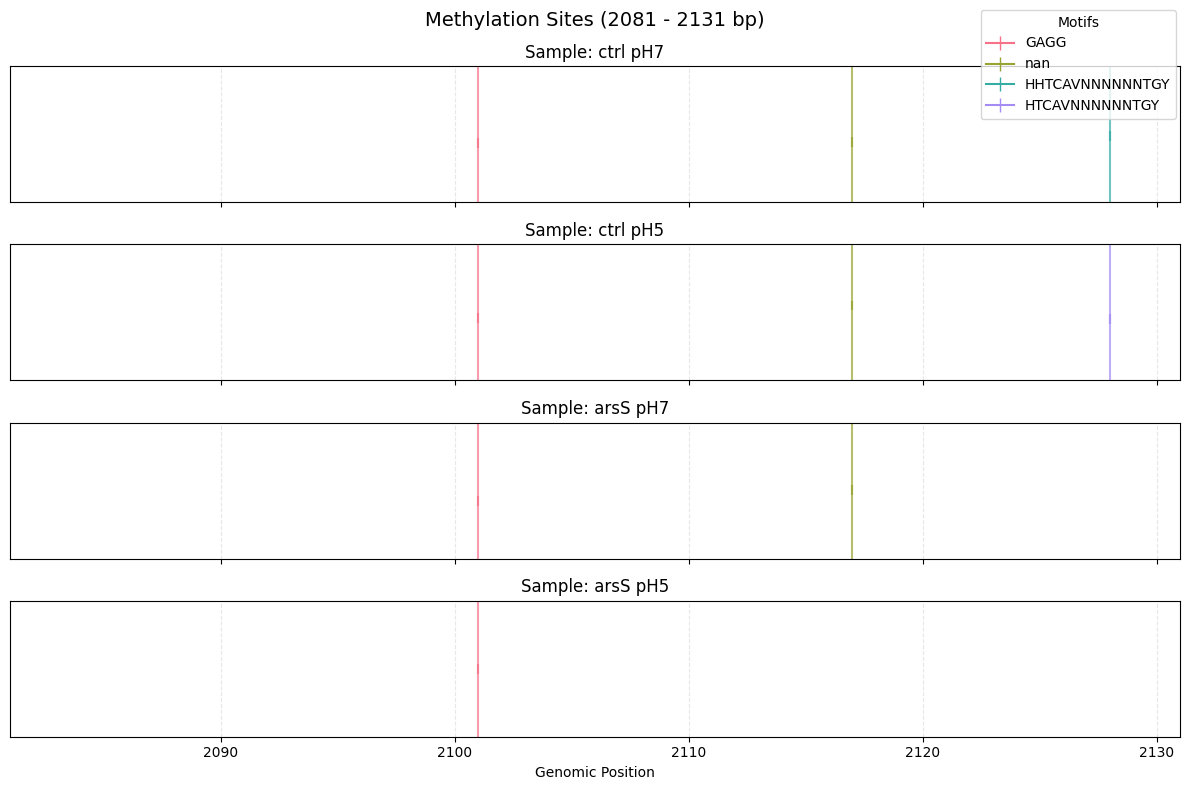

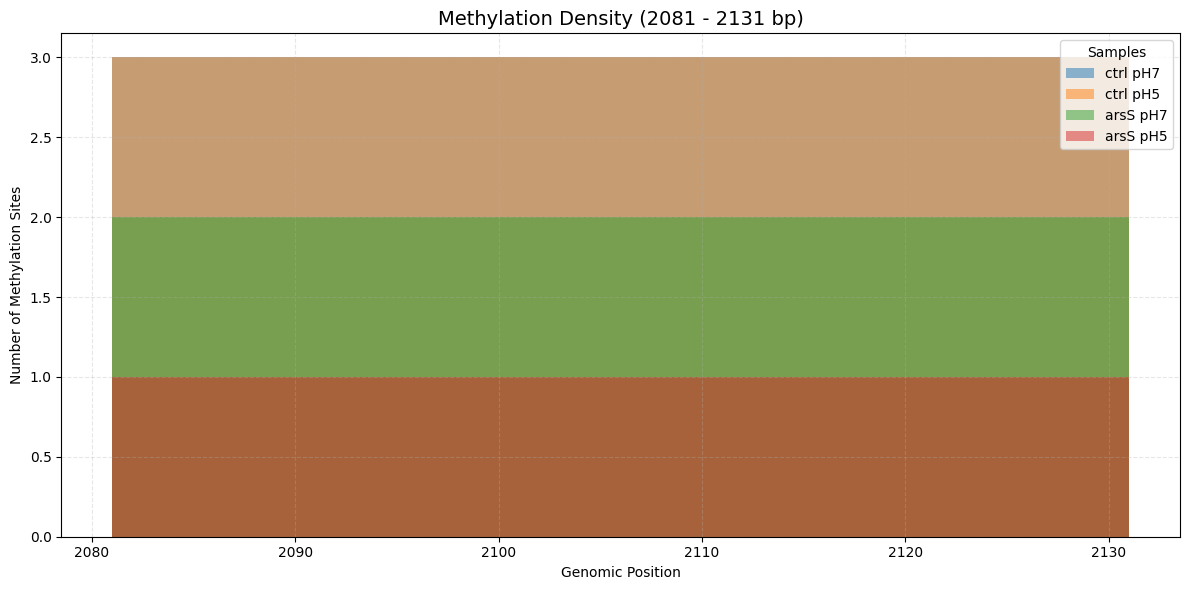

In [23]:
#Define the region you want to analyze
start_position = 2081	  # Replace with your desired start position
end_position = 2131   # Replace with your desired end position
analyze_methylation_region(merged, start_position, end_position)

In [24]:
merged[(merged['start'] >= 2081 ) & ( merged['start'] <= 2131)]

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
74,74,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,621,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,556,GAGG,587.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
75,75,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,137,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,559,NaN,85.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
76,76,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2128,2128,135,+,.,...,TGAGTTGCAAGCGCGCATTCAAACGCTCTGTAAGCCATGAA,527,HHTCAVNNNNNNTGY,85.0,HHTCAVNNNNNNTGY,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
59754,59754,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,521,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,440,GAGG,492.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
59755,59755,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,160,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,446,NaN,122.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
59756,59756,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2128,2128,115,+,.,...,TGAGTTGCAAGCGCGCATTCAAACGCTCTGTAAGCCATGAA,423,HTCAVNNNNNNTGY,75.0,HTCAVNNNNNNTGY,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
119420,119420,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,540,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,526,GAGG,508.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
119421,119421,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,113,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,531,NaN,71.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
178332,178332,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,503,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,483,GAGG,484.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE


In [45]:
diff_ctrl = pd.read_csv('./differences/control_differences.csv')
diff_ctrl[diff_ctrl['start'] <= 1319483]

,Unnamed: 0.1,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,...,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
0,0,107,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2946,2946,122,+,...,coverage=544;context=GCAAATGCCGCACTAGAATGCGCGA...,2.03,GCAAATGCCGCACTAGAATGCGCGAAATTAGACATTGACAT,544,NaN,59.0,NaN,coding region,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES"
1,1,191,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,5835,5835,127,+,...,coverage=521;context=TTATGCCCTAATTCTTGCGTGGCGC...,2.03,TTATGCCCTAATTCTTGCGTGGCGCTTAATAATTGCGAATA,521,NaN,NaN,NaN,coding region,HP0009,CELL ENVELOPE
2,2,195,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,6033,6033,108,+,...,coverage=526;context=CTAAAATCAAGTATCGTGCGCGCCA...,2.04,CTAAAATCAAGTATCGTGCGCGCCAACAACTCAGATTGCTT,526,NaN,26.0,NaN,coding region,HP0009,CELL ENVELOPE
3,3,237,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,7151,7151,123,+,...,coverage=511;context=GGTGTTTTTCACCATTTGAGCGGCT...,2.02,GGTGTTTTTCACCATTTGAGCGGCTTCACCGATTTGATAGC,511,NaN,66.0,NaN,intergenic region,NaN,NaN
4,4,258,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,7831,7831,127,+,...,coverage=469;context=CTAGCGTTAAAACCAAAATGCCCTT...,2.07,CTAGCGTTAAAACCAAAATGCCCTTCGTGTTTTTCTACTTC,469,NaN,102.0,NaN,coding region,HP0010,CELLULAR PROCESSES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,994,106576,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,1314363,1314363,120,+,...,coverage=430;context=TTAGCCCACACATTCGCTTTTATGG...,2.14,TTAGCCCACACATTCGCTTTTATGGGCGCGTTTTTCACCCC,430,NaN,NaN,NaN,coding region,HP1241,TRANSLATION
995,995,106577,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,1314367,1314367,113,+,...,coverage=428;context=CCCACACATTCGCTTTTATGGGCGC...,2.00,CCCACACATTCGCTTTTATGGGCGCGTTTTTCACCCCGCAT,428,NaN,NaN,NaN,coding region,HP1241,TRANSLATION
996,996,106579,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1314379,1314379,122,+,...,context=CTTTTATGGGCGCGTTTTTCACCCCGCATGCGAGAGTG...,2.11,CTTTTATGGGCGCGTTTTTCACCCCGCATGCGAGAGTGATT,423,HTCAVNNNNNNTGY,109.0,HTCAVNNNNNNTGY,coding region,HP1241,TRANSLATION
997,997,106673,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1316493,1316493,102,+,...,context=GAGAAATTCCCTAGCATTTCAAAAAGCGTGTGGTGCCT...,2.07,GAGAAATTCCCTAGCATTTCAAAAAGCGTGTGGTGCCTTGC,396,HTCAVNNNNNNTGY,68.0,HTCAVNNNNNNTGY,coding region,HP1241,TRANSLATION


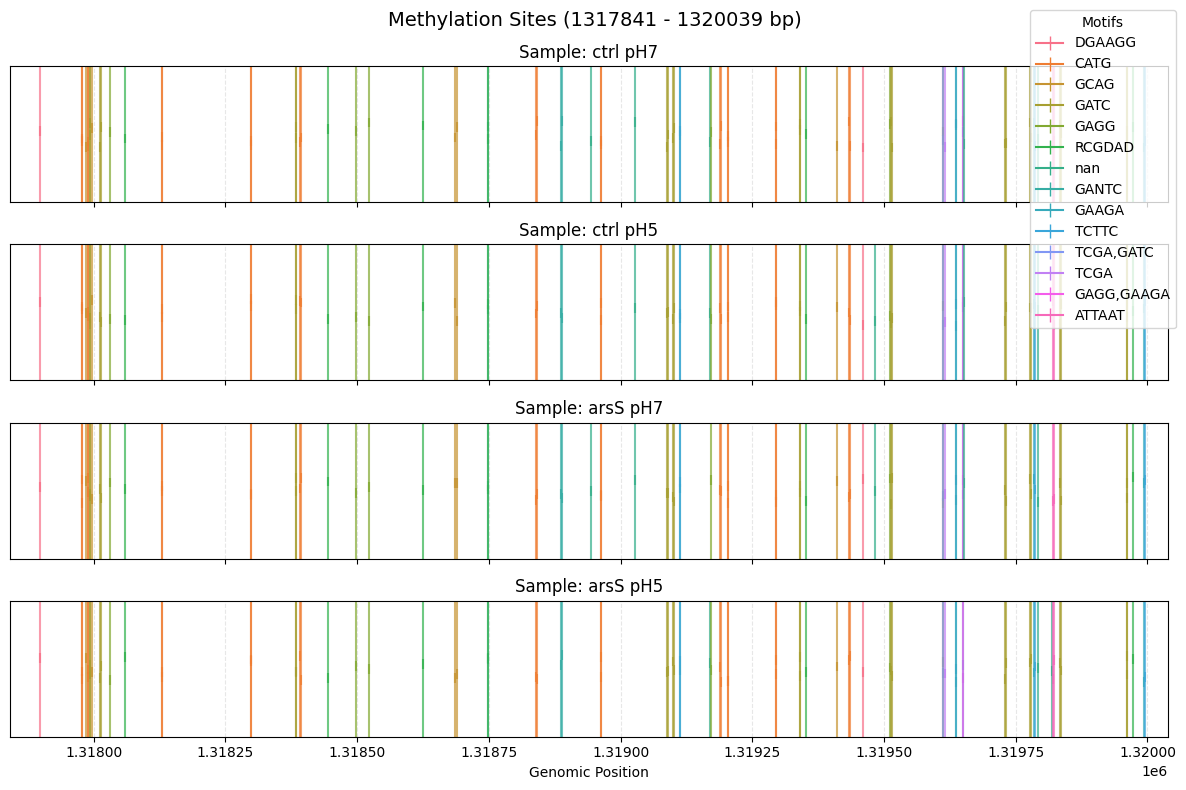

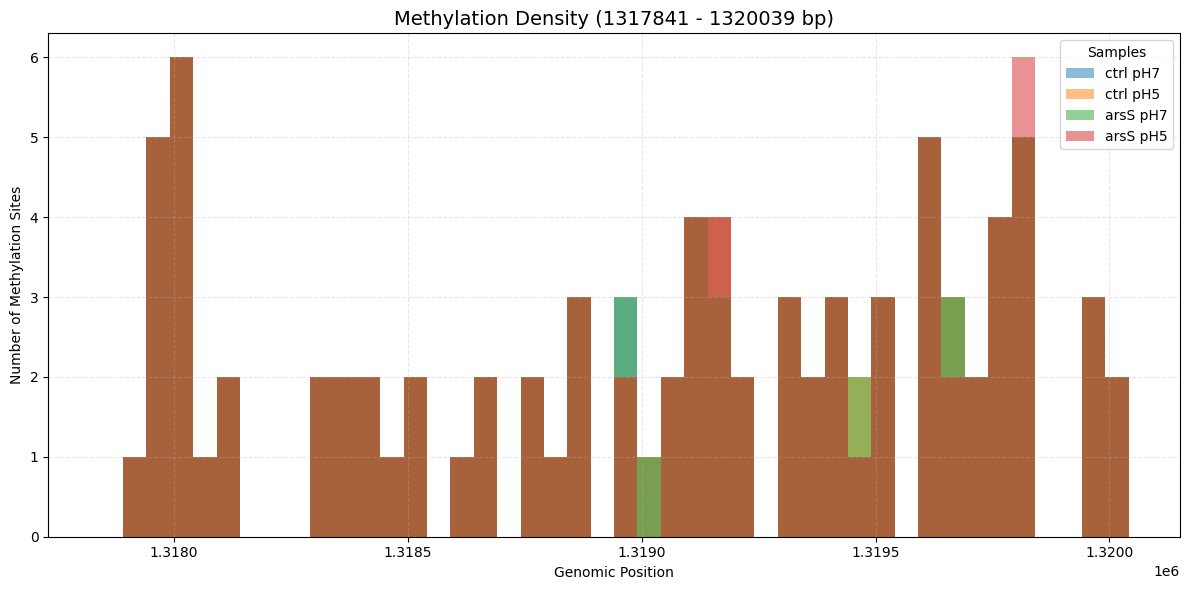

In [26]:
#Define the region you want to analyze
start_position = 1317841	  # Replace with your desired start position
end_position = 1320039   # Replace with your desired end position
analyze_methylation_region(merged, start_position, end_position)

In [25]:
annot[annot['HP_number'] == 'HP1243']

,HP_number,start,end,Putative_Id,Orf_Size,strand
1242,HP1243,1317841,1320039,outer membrane protein (omp28),2198,-


In [30]:
ph7_unique[(ars_unique['start'] >= 1317841 ) & (ars_unique['start'] <= 1320039)]

NameError: name 'ph7_unique' is not defined

In [27]:
merged[(merged['start'] >= 2081 ) & (merged['start'] <= 2131)]

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
74,74,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,621,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,556,GAGG,587.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
75,75,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,137,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,559,NaN,85.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
76,76,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2128,2128,135,+,.,...,TGAGTTGCAAGCGCGCATTCAAACGCTCTGTAAGCCATGAA,527,HHTCAVNNNNNNTGY,85.0,HHTCAVNNNNNNTGY,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
59754,59754,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,521,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,440,GAGG,492.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
59755,59755,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,160,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,446,NaN,122.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
59756,59756,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2128,2128,115,+,.,...,TGAGTTGCAAGCGCGCATTCAAACGCTCTGTAAGCCATGAA,423,HTCAVNNNNNNTGY,75.0,HTCAVNNNNNNTGY,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
119420,119420,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,540,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,526,GAGG,508.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
119421,119421,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,113,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,531,NaN,71.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
178332,178332,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,503,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,483,GAGG,484.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE


In [22]:
ctrl5[(ctrl5['start'] >= 2081 ) & ( ctrl5['start'] <= 2131)]

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
59754,59754,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,521,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,440,GAGG,492.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
59755,59755,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,160,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,446,NaN,122.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
59756,59756,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2128,2128,115,+,.,...,TGAGTTGCAAGCGCGCATTCAAACGCTCTGTAAGCCATGAA,423,HTCAVNNNNNNTGY,75.0,HTCAVNNNNNNTGY,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE


In [18]:
annot[annot['HP_number'] == 'HP1414']

,HP_number,start,end,Putative_Id,Orf_Size,strand
1413,HP1414,1484535,1484873,conserved hypothetical protein {Haemophilus in...,338,+
